<a href="https://colab.research.google.com/github/AnzorGozalishvili/IOAI-2025-lectures/blob/main/lecture_31_transformers_finetuning_on_classification/notebooks/DGurgurov_xlm_r_georgian_sentiment_Analyzing_Model_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DGurgurov/xlm-r_georgian_sentiment

- Model Card: https://huggingface.co/DGurgurov/xlm-r_georgian_sentiment
- dataset on huggingface: https://huggingface.co/datasets/DGurgurov/georgian_sa/viewer/default/test?views%5B%5D=test
- Dataset Source: https://github.com/pyRis/retrofitting-embeddings-lrls?tab=readme-ov-file

### class label map
- https://huggingface.co/Arseniy-Sandalov/GeorgianBert-Sent/blob/main/config.json

```json
{
  "0": "Negative",
  "1": "Positive"
}
```

In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("DGurgurov/xlm-r_georgian_sentiment")
model = AutoModelForSequenceClassification.from_pretrained("DGurgurov/xlm-r_georgian_sentiment")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/781 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

In [2]:
import torch

CLASSES = ['Negative', 'Positive']

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def predict_sentiment(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    # Move input tensors to the GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    predictions = outputs.logits.argmax(dim=1).cpu().tolist()
    return [CLASSES[prediction] for prediction in predictions]

text = "ლაშა ტალახაძე ფიორდეში დასრულებულ ევროპის ჩემპიონატზე ოქროს მედლის მფლობელია"
print(predict_sentiment([text, text, text]))

['Positive', 'Positive', 'Positive']


# Evaluate on Sentiment Dataset

In [3]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [22]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("DGurgurov/georgian_sa")
print(dataset)
pd.concat([pd.Series(dataset[split]['label']).value_counts().T for split in ['train', 'validation', 'test']], axis=1, keys=['train', 'validation', 'test'])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1080
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 120
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 330
    })
})


,train,validation,test
0,550,50,165
1,530,70,165


## Evaluate

In [27]:
from torch.utils.data import DataLoader, TensorDataset

label_to_id = {k:idx for idx,k in enumerate(CLASSES)}
id_to_label = {idx:k for idx,k in enumerate(CLASSES)}

def create_dataloader(dataset, tokenizer, batch_size=32, max_length=512):
    texts = [example['text'] for example in dataset]
    label_ids = [example['label'] for example in dataset]  # Assuming 'label' key exists
    labels = [id_to_label[label_id] for label_id in label_ids]

    # Tokenize the texts
    encoded_inputs = tokenizer(texts, truncation=True, padding='max_length', max_length=max_length, return_tensors='pt')

    # Create TensorDataset
    dataset = TensorDataset(encoded_inputs['input_ids'], encoded_inputs['attention_mask'], torch.tensor(label_ids))

    # Create DataLoader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # Set shuffle=False for inference

    return dataloader


# Example Usage
batch_size = 256  # Adjust as needed
val_dataloader = create_dataloader(dataset['validation'], tokenizer, batch_size=batch_size) # Use 'validation' split
test_dataloader = create_dataloader(dataset['test'], tokenizer, batch_size=batch_size) # Use 'test' split

In [29]:
next(iter(val_dataloader)), next(iter(test_dataloader))

([tensor([[     0,  72298,  21171,  ...,      1,      1,      1],
          [     0,    325,  83913,  ...,      1,      1,      1],
          [     0, 128299,      6,  ...,      1,      1,      1],
          ...,
          [     0,  69000,  46102,  ...,      1,      1,      1],
          [     0, 216821,   7257,  ...,      1,      1,      1],
          [     0,  38917,      6,  ...,      1,      1,      1]]),
  tensor([[1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          ...,
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0]]),
  tensor([0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
          1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
          1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
          0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
          1, 0, 1, 1, 1, 1

In [31]:
def predict_batch(batch, model):
    model.eval()
    input_ids, attention_mask, labels = batch
    with torch.no_grad():
        # Move inputs to the device
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = outputs.logits.argmax(dim=1).cpu().tolist()
        probabilities = outputs.logits.softmax(dim=1).cpu().tolist()
        labels = labels.tolist()

    return predictions, probabilities, labels

batch_preds, batch_probs, batch_labels = predict_batch(batch=next(iter(val_dataloader)), model=model)
print(batch_preds[:10], batch_probs[:10], batch_labels[:10])

[0, 0, 1, 1, 1, 0, 1, 0, 1, 0] [[0.9985426664352417, 0.0014573662774637341], [0.9986924529075623, 0.0013076054165139794], [0.04019860923290253, 0.9598013162612915], [0.03308932110667229, 0.966910719871521], [0.03182322159409523, 0.9681767821311951], [0.9985363483428955, 0.0014636653941124678], [0.040894877165555954, 0.9591051340103149], [0.9932015538215637, 0.0067984783090651035], [0.031816188246011734, 0.9681838154792786], [0.9978971481323242, 0.002102854661643505]] [0, 0, 1, 1, 1, 0, 1, 0, 1, 0]


In [35]:
from tqdm import tqdm

def batch_predict_sentiment(dataloader, model):
    all_predictions = []
    all_probabilities = []
    all_labels = []

    for batch in tqdm(dataloader):
        predictions, probabilities, labels = predict_batch(batch, model)

        all_predictions.extend(predictions)
        all_labels.extend(labels)
        all_probabilities.extend(probabilities)

    return all_predictions, all_probabilities, all_labels

val_predictions, val_probabilities, val_labels = batch_predict_sentiment(val_dataloader, model)
test_predictions, test_probabilities, test_labels = batch_predict_sentiment(test_dataloader, model)

100%|██████████| 2/2 [00:16<00:00,  8.24s/it]


              precision    recall  f1-score   support

    Negative       0.96      0.90      0.93        50
    Positive       0.93      0.97      0.95        70

    accuracy                           0.94       120
   macro avg       0.94      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120



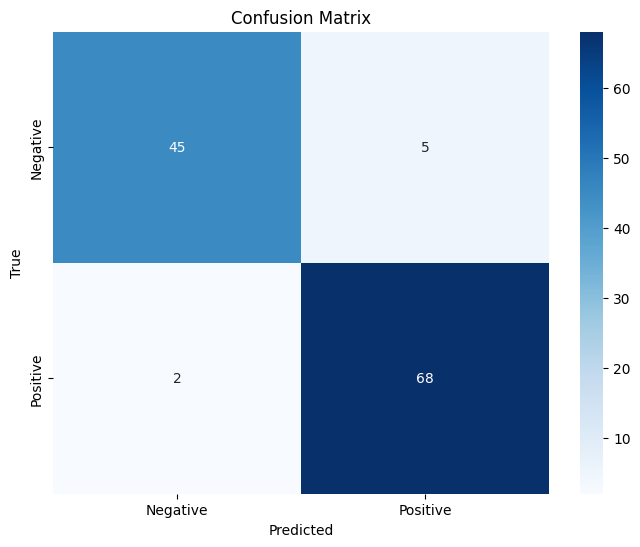

Macro F1-Score: 0.9394420012976714
AUC-ROC (OVO, macro): 0.9742857142857144
              precision    recall  f1-score   support

    Negative       0.92      0.79      0.85       165
    Positive       0.82      0.93      0.87       165

    accuracy                           0.86       330
   macro avg       0.87      0.86      0.86       330
weighted avg       0.87      0.86      0.86       330



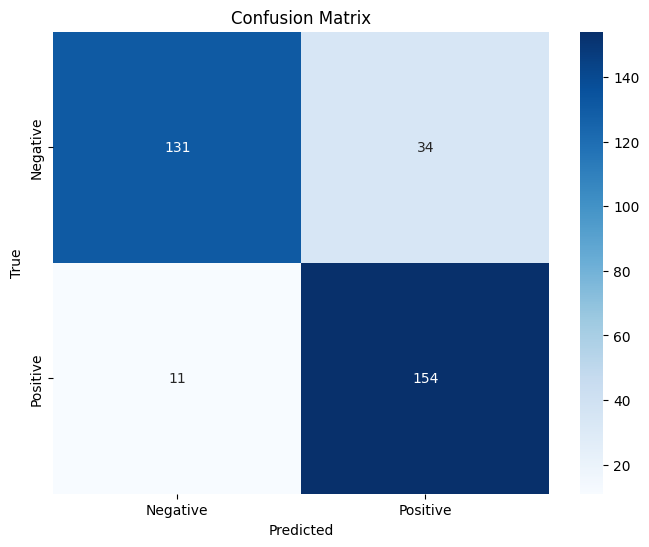

Macro F1-Score: 0.8629707209493315
AUC-ROC (OVO, macro): 0.9527272727272726


In [36]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def classification_reports(true_labels, predicted_labels, predicted_probabilities):

    # Classification Report
    print(classification_report(true_labels, predicted_labels, target_names=CLASSES))

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES,
                yticklabels=CLASSES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # F1-Score (macro average)
    f1 = f1_score(true_labels, predicted_labels, average='macro')
    print(f"Macro F1-Score: {f1}")


    # AUC-ROC (requires probabilities)
    try:
        auc_roc = roc_auc_score(np.eye(4)[true_labels], np.array(predicted_probabilities), multi_class='ovo', average='macro')
        print(f"AUC-ROC (OVO, macro): {auc_roc}")
    except ValueError as e:
        print(f"AUC-ROC Calculation failed: {e}")

classification_reports(true_labels=val_labels, predicted_labels=val_predictions, predicted_probabilities=val_probabilities)
classification_reports(true_labels=test_labels, predicted_labels=test_predictions, predicted_probabilities=test_probabilities)

# Let's explore Georgian vocabulary and how it tokenizes text

The statistics of our interest:
- total Georgian tokens
- percentage of Georgian tokens in full vocab
- average Georgian token length vs Latin Token lengths
- average token length in our dataset

In [37]:
import re

georgian_alphabet = "აბგდევზთიკლმნოპჟრსტუფქღყშჩცძწჭხჯჰ"
latin_alphabet = "abcdefghijklmnopqrstuvwxyz"

def is_georgian(token):
  return bool(re.search(f"[{georgian_alphabet}]", token))

def is_latin(token):
  return bool(re.search(f"[{latin_alphabet}]", token))


georgian_tokens = 0
latin_tokens = 0
georgian_token_lengths = []
latin_token_lengths = []
all_token_lengths = []

for token in tokenizer.vocab:
  all_token_lengths.append(len(token))
  if is_georgian(token):
    georgian_tokens +=1
    georgian_token_lengths.append(len(token))
  elif is_latin(token):
    latin_tokens += 1
    latin_token_lengths.append(len(token))


print(f"Total Georgian tokens: {georgian_tokens}")
print(f"Percentage of Georgian tokens in full vocab: {(georgian_tokens / len(tokenizer.vocab)) * 100:.2f}%")

if georgian_token_lengths:
    avg_georgian_token_length = sum(georgian_token_lengths) / len(georgian_token_lengths)
else:
    avg_georgian_token_length = 0

if latin_token_lengths:
    avg_latin_token_length = sum(latin_token_lengths) / len(latin_token_lengths)
else:
    avg_latin_token_length = 0

print(f"Average Georgian token length: {avg_georgian_token_length:.2f}")
print(f"Average Latin token length: {avg_latin_token_length:.2f}")

avg_token_length_dataset = sum(all_token_lengths) / len(all_token_lengths)
print(f"Average token length in the tokenizer vocab: {avg_token_length_dataset:.2f}")


Total Georgian tokens: 3762
Percentage of Georgian tokens in full vocab: 1.50%
Average Georgian token length: 5.71
Average Latin token length: 6.76
Average token length in the tokenizer vocab: 5.55


In [38]:
# prompt: average token length in our dataset

avg_token_length_dataset = sum(all_token_lengths) / len(all_token_lengths)
print(f"Average token length in the tokenizer vocabulary: {avg_token_length_dataset:.2f}")

token_lengths_in_dataset = []
for example in dataset['train']:
    tokens = tokenizer.tokenize(example['text'])
    token_lengths_in_dataset.extend([len(token) for token in tokens])

avg_token_length_in_dataset = sum(token_lengths_in_dataset) / len(token_lengths_in_dataset) if token_lengths_in_dataset else 0

print(f"Average token length in the dataset: {avg_token_length_in_dataset:.2f}")


Average token length in the tokenizer vocabulary: 5.55
Average token length in the dataset: 3.92


In [39]:
# prompt: Show 100 examples of tokenized text. print full text and then tokens comma separated

example_texts = dataset['train']['text'][:100]

for text in example_texts:
  tokens = tokenizer.tokenize(text)
  print(text)
  print(*tokens, sep=", ")
  print("---")

ლაშა ტალახაძე ფიორდეში დასრულებულ ევროპის ჩემპიონატზე ოქროს მედლის მფლობელია
▁ლაშა, ▁, ტალ, ახ, აძე, ▁ფი, ორ, დე, ში, ▁და, სრულ, ებულ, ▁ევროპის, ▁, ჩემპიონ, ატ, ზე, ▁ოქროს, ▁, მედ, ლის, ▁მფლობელ, ია
---
პროკურატურა მოქცეულია ჩიხში, - აცხადებს ჯოგლიძე"
▁პროკურატურა, ▁მო, ქცე, ულია, ▁ჩი, ხ, ში, ,, ▁-, ▁აცხადებს, ▁, ჯო, გ, ლი, ძე, "
---
საგამომცელო საქმეს ბოლოს ქვეყანაში შექმნილმა ეკონომიკურმა ვითარებამ და ლარის გაუფასურებამ დაარტყა, პირველი და მთავარი დარტყმა კი მათ ორი წლის წინ მიიღეს
▁სა, გამო, მც, ელო, ▁საქმე, ს, ▁ბოლოს, ▁ქვეყანაში, ▁შექმნ, ილ, მა, ▁, ეკონომი, კურ, მა, ▁ვითარება, მ, ▁და, ▁ლარი, ს, ▁გაუ, ფას, ურ, ება, მ, ▁და, არტ, ყა, ,, ▁პირველი, ▁და, ▁მთავარი, ▁დარ, ტყ, მა, ▁კი, ▁მათ, ▁ორი, ▁წლის, ▁წინ, ▁მიიღე, ს
---
ლარის გაუფასურების გადაფარვის მცდელობა- ქადაგიძის პასუხი ბიძინა ივანიშვილს"
▁ლარი, ს, ▁გაუ, ფას, ურ, ების, ▁გადა, ფარ, ვის, ▁მც, დელ, ობა, -, ▁ქა, და, გ, იძის, ▁პასუხი, ▁ბიძინა, ▁ი, ვანი, შვილს, "
---
დავით ზალკალიანის განმარტებით, მუდმივად მიმდინარეობს საუბარი იმ საკითხ